## 06_scatter_matrix

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### создайте фрейм данных, в котором у каждого пользователя тестовой группы будет средняя разница, количество просмотров страниц и количество коммитов

In [2]:
commits = pd.read_sql(
    """
    SELECT uid, COUNT(*) AS num_commits
    FROM checker
    WHERE labname != 'project1'
    GROUP BY uid
    """,
    conn,
)
commits

,uid,num_commits
0,None,4
1,admin_1,7
2,admin_2,1
3,user_0,3
4,user_1,62
5,user_10,20
6,user_11,7
7,user_12,86
8,user_13,52
9,user_14,61


In [3]:
views = pd.read_sql(
    """ 
    SELECT 
        test.uid,
        AVG((CAST(strftime('%s', first_commit_ts) AS first) - deadlines) / 3600) AS avg_diff,
        COUNT(*) AS pageviews         
    FROM test
    LEFT JOIN deadlines ON deadlines.labs = test.labname
    LEFT JOIN pageviews ON pageviews.uid = test.uid
    WHERE test.labname != 'project1'
    GROUP BY test.uid
    
    """,
    conn,
)
views

,uid,avg_diff,pageviews
0,user_1,-64.400000,140
1,user_10,-74.800000,445
2,user_14,-159.000000,429
3,user_17,-61.600000,235
4,user_18,-5.666667,9
5,user_19,-98.750000,64
6,user_21,-95.500000,40
7,user_25,-92.600000,895
8,user_28,-86.400000,745
9,user_3,-105.400000,1585


In [4]:
df = views.merge(commits)
df.corr(numeric_only=True)

,avg_diff,pageviews,num_commits
avg_diff,1.000000,-0.185834,-0.304931
pageviews,-0.185834,1.000000,-0.186776
num_commits,-0.304931,-0.186776,1.000000


### берем количество коммитов из контрольной таблицы размер рисунка остался прежним, вы можете выбрать любой размер шрифта, который вам нравится, а также цветовую палитру, размер точек должен быть 200, ширина линий диагональных графиков (kde) должна быть равна 3

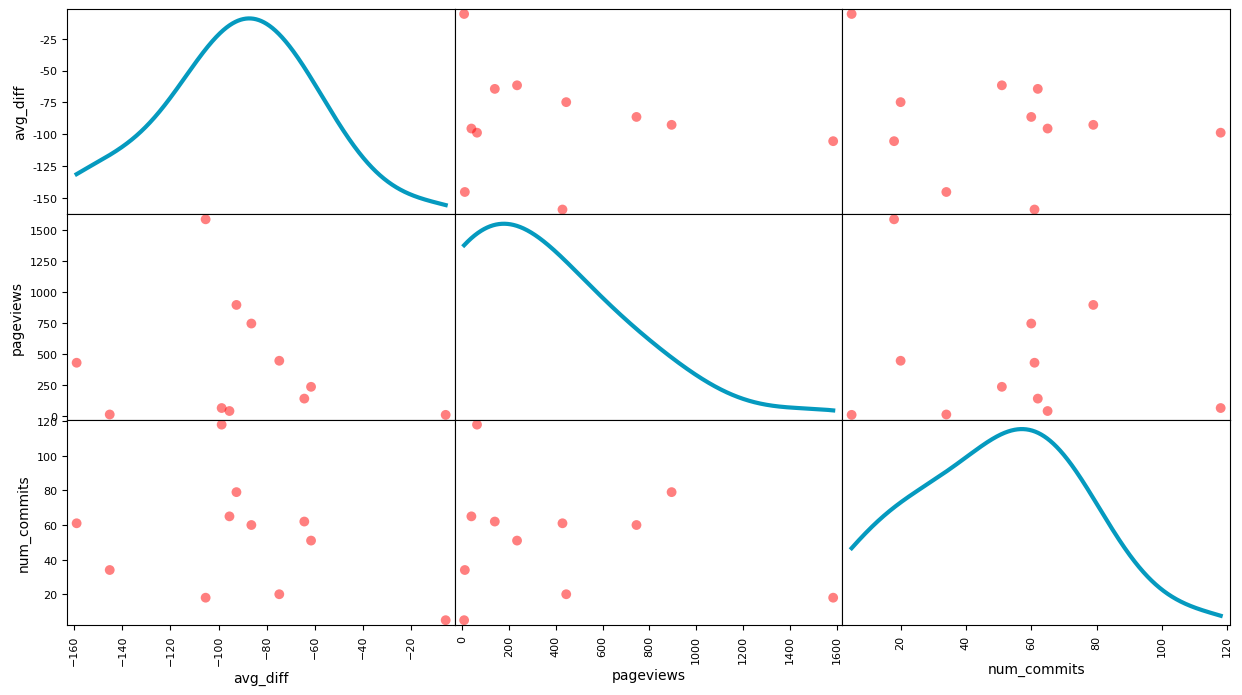

In [5]:
ax = scatter_matrix(
    df,
    figsize=(15, 8),
    diagonal="kde",
    density_kwds=dict(color="#059ABF", linewidth=3),
    s=200,
    color="red",
)

### “Можем ли мы сказать, что если у пользователя мало просмотров страниц, то у него, вероятно, мало коммитов? Ответ - нет.
### Можем ли мы сказать, что если у пользователя небольшое количество просмотров страниц, то у него, вероятно, небольшая средняя разница между первым коммитом и крайним сроком лабораторной работы? Ответ - нет.
### Можем ли мы сказать, что есть много пользователей с небольшим количеством коммитов и несколько с большим количеством коммитов? Ответ - да.
### Можно ли сказать, что есть много пользователей с небольшой средней разницей и несколько пользователей с большой средней разницей? Ответ - нет.

In [6]:
conn.close()